## 4_3. 앙상블 학습 개요

1. 정의 : 여러 개의 분류기를 생성하고, 그 예측을 결합함으로써 보다 정확한 최종 예측을 도출하는 기법.
2. 특징
   1) 정형 데이터 분류 시에 뛰어난 성능을 보임.
   2) 랜덤 포레스트, 그래디언트 부스팅 알고리즘이 대표적.
3. 유형
   1) 보팅 : 여러 개의 분류기(서로 다른 알고리즘을 가짐)가 투표를 통해 최종 예측 결과를 결정하는 방식.
   2) 배깅 : 여러 개의 분류기(모두 같은 알고리즘 기반)가 투표를 통해 최종 예측 결과를 결정하는 방식.
      - '부트스트래핑(원본 학습 데이터에서 데이터를 샘플링 해서 추출)'으로 데이터 세트 샘플링
      - 샘플링된 데이터 세트에 대하여 개별 예측을 수행한 결과를 보팅을 통해 최종 예측 / 중첩 허용
   3) 부스팅: 앞에서 학습한 분류기가 틀리게 예측한 데이터에 대해 다음 분류기는 잘 예측할 수 있도록 '가중치'를 부여하는 방식.
   4) 스태킹 : 여러 가지 다른 모델의 예측 결괏값을다시 학습 데이터로 만든 '메타 모델'로 재학습시켜 결과를 예측하는 모델.

### 보팅(Voting) Classifier
1. 하드 보팅
   : 다수결 원칙
3. 소프트 보팅
   : 분류기들의 레이블 값 결정 확률을 모두 더하고, 이를 평균하여 이들 중 확률이 가장 높은 레이블 값을 최종 결괏값으로 선정.

### 보팅 분류기 만들기
- 위스콘신 유방암 데이터 세트 사용 : 유방암의 악성종양/양성종양 여부 결정하는 이진 분류 데이터 세트
- 보팅 분류기를 만들 개별 모델 : 로지스틱 회귀, KNN 사용
- 소프트 보팅 방식 사용

In [5]:
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [6]:
# 개별 모델 1 : 로지스틱 회귀 모델
lr_clf = LogisticRegression(solver='liblinear')
# 개별 모델 2 : KNN 분류 모델
knn_clf = KNeighborsClassifier(n_neighbors=8)

# VotingClassifier 클래스 이용 -> 보팅 분류기 생성
# 주요 생성 인자: estimators(사용 모델), voting(hard 인지 soft인지. hard가 기본)
vo_clf = VotingClassifier( estimators=[('LR',lr_clf),('KNN',knn_clf)] , voting='soft' )

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, 
                                                    test_size=0.2 , random_state= 156)

# VotingClassifier 학습/예측/평가. 
vo_clf.fit(X_train , y_train)
pred = vo_clf.predict(X_test)
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test , pred)))

# 개별 모델의 학습/예측/평가.
classifiers = [lr_clf, knn_clf]
for classifier in classifiers:
    classifier.fit(X_train , y_train)
    pred = classifier.predict(X_test)
    class_name= classifier.__class__.__name__
    print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test , pred)))

Voting 분류기 정확도: 0.9561
LogisticRegression 정확도: 0.9474
KNeighborsClassifier 정확도: 0.9386


- 결과 : 보팅 분류기가 개별 모델들의 예측 성능보다 성능이 더 좋았다.

## 4_4. 배깅(Bagging) Classifier - 랜덤 포레스트

- 부트스트래핑 분할 방식(여러 개의 데이터 세트를 만들 때, 원본 데이터에서 중첩되게 샘플링하는 것)
- 부트스트래핑으로 분할한 개별 데이터 세트에 결정 트리 분류기를 각각 적용하는 것(하나씩 매칭)이 랜덤 포레스트

In [10]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x : x.iloc[0]+'_'+str(x.iloc[1]) 
                                                                                         if x.iloc[1] >0 else x.iloc[0] ,  axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

In [11]:
import pandas as pd

def get_human_dataset( ):
    
    # 각 데이터 파일들은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당.
    feature_name_df = pd.read_csv('features.txt',sep=r'\s+',
                        header=None,names=['column_index','column_name'])
    
    # 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용, 신규 피처명 DataFrame생성. 
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    
    # DataFrame에 피처명을 컬럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    
    # 학습 피처 데이터 셋과 테스트 피처 데이터을 DataFrame으로 로딩. 컬럼명은 feature_name 적용
    X_train = pd.read_csv('X_train.txt',sep=r'\s+', names=feature_name )
    X_test = pd.read_csv('X_test.txt',sep=r'\s+', names=feature_name)
    
    # 학습 레이블과 테스트 레이블 데이터을 DataFrame으로 로딩하고 컬럼명은 action으로 부여
    y_train = pd.read_csv('y_train.txt',sep=r'\s+',header=None,names=['action'])
    y_test = pd.read_csv('y_test.txt',sep=r'\s+',header=None,names=['action'])
    
    # 로드된 학습/테스트용 DataFrame을 모두 반환 
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = get_human_dataset()

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 결정 트리에서 사용한 get_human_dataset( )을 이용해 학습/테스트용 DataFrame 반환
X_train, X_test, y_train, y_test = get_human_dataset()

# 랜덤 포레스트 학습 및 별도의 테스트 셋으로 예측 성능 평가
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train , y_train)
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test , pred)
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9253


- 랜덤 포레스트가 사용자 행동 인식 데이터 세트에 대해 약 92.53%의 정확도를 보여줌.

### 랜덤 포레스트 하이퍼 파라미터 및 튜닝
- 랜덤 포레스트의 단점) 하이퍼 파라미터가 너무 많아 튜닝을 많이 해야됨.
- 하이퍼 파라미터 종류: n_estimators(결정트리의개수), max_features, max_depth(과적합개선) 등.

[GridSearchCV를 이용한 랜덤 포레스트 하이퍼 파라미터 튜닝]

In [16]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100],
    'max_depth' : [6, 8, 10, 12], 
    'min_samples_leaf' : [8, 12, 18 ],
    'min_samples_split' : [8, 16, 20]
}
# RandomForestClassifier 객체 생성 후 GridSearchCV 수행
rf_clf = RandomForestClassifier(random_state=0, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf , param_grid=params , cv=2, n_jobs=-1 )
grid_cv.fit(X_train , y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}
최고 예측 정확도: 0.9180


- 추출된 최적 하이퍼 파라미터로 다시 RandomForestClassifier 학습시키기
- test 데이터에서 예측 성능 측정

In [18]:
rf_clf1 = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=8, \
                                 min_samples_split=8, random_state=0)
rf_clf1.fit(X_train , y_train)
pred = rf_clf1.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test , pred)))

예측 정확도: 0.9196


- 피처 중요도 막대그래프 시각화

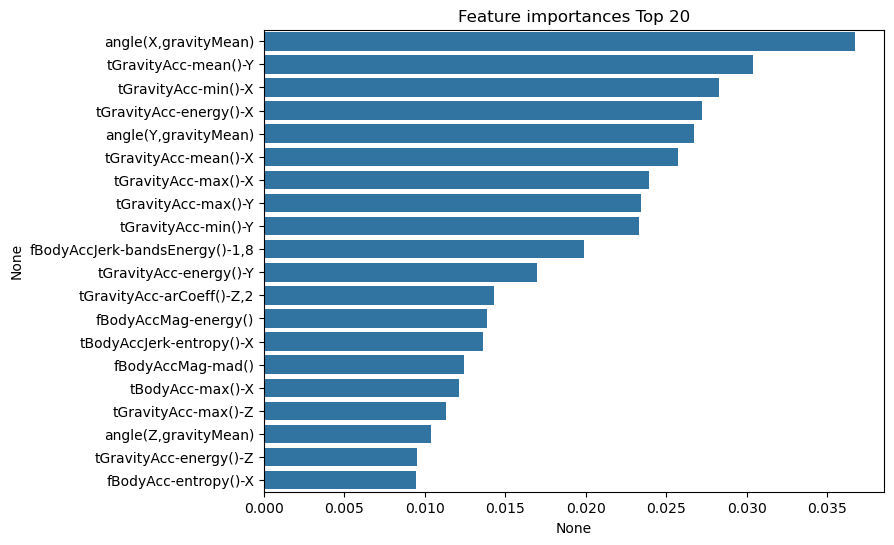

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ftr_importances_values = rf_clf1.feature_importances_
ftr_importances = pd.Series(ftr_importances_values,index=X_train.columns  )
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20 , y = ftr_top20.index)
fig1 = plt.gcf()
plt.show()
plt.draw()
fig1.savefig('rf_feature_importances_top20.tif', format='tif', dpi=300, bbox_inches='tight')

- angle(X,gravityMean)이 가장 높은 피처 중요도를 가지고 있음.

## 4_5. 부스팅 Classifier - GBM(Gradient Boosing Machine)
- 가중치 업데이트 시 '경사 하강법(Gradient Descent)'을 이용

[GradientBoostingClassifier 클래스 이용하여 사용자 행동 데이터 세트 예측 분류]

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

# 데이터 세트 가져기기
X_train, X_test, y_train, y_test = get_human_dataset()

# GBM 수행 시간 측정을 위함. 시작 시간 설정.
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train , y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print("GBM 수행 시간: {0:.1f} 초 ".format(time.time() - start_time))